# Passing Quality Model — Refined

Based on notebook 01 findings, we drop non-significant delta team qualities
(CHANCE_CREATION, PENETRATION, ATTACKING_TRANSITION) and keep only:

- **ATTACK** (p < 0.001)
- **DEFENCE** (p < 0.001)
- **OUTCOME** (p < 0.001)
- **DEFENSIVE_TRANSITION** (p = 0.08, marginal but theoretically grounded)

In [13]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [14]:
# ── Load & prepare ──
DATA_DIR = "../../../../thesis_data/processed_data/thesis_model_dataset/active/"
df = pd.read_parquet(DATA_DIR + "within_league_transfers_v5.parquet")
mf = df[df["from_position"] == "Midfielder"].copy()

# Target
mf["delta_Passing_quality"] = mf["to_Passing quality"] - mf["from_Passing quality"]

# All 7 team quality deltas (compute all, select later)
ALL_TQ = ["ATTACK", "ATTACKING_TRANSITION", "CHANCE_CREATION",
          "DEFENCE", "DEFENSIVE_TRANSITION", "OUTCOME", "PENETRATION"]

for tq in ALL_TQ:
    mf[f"delta_tq_{tq}"] = mf[f"to_q_{tq}"] - mf[f"from_q_proj_{tq}"]

# Refined selection: only significant deltas
SELECTED_TQ = ["ATTACK", "DEFENCE", "OUTCOME", "DEFENSIVE_TRANSITION"]
delta_tq_cols = [f"delta_tq_{tq}" for tq in SELECTED_TQ]

# Drop NaNs
cols_needed = ["from_Passing quality", "delta_Passing_quality"] + delta_tq_cols
n_before = len(mf)
mf = mf.dropna(subset=cols_needed)
print(f"Dropped {n_before - len(mf)} rows with missing data")
print(f"Remaining: {len(mf):,}")

Dropped 314 rows with missing data
Remaining: 4,916


In [15]:
# Train/test split (same seed as notebook 01)
train, test = train_test_split(mf, test_size=0.2, random_state=42)
y_train = train["delta_Passing_quality"]
y_test  = test["delta_Passing_quality"]
print(f"Train: {len(train):,}  |  Test: {len(test):,}")

Train: 3,932  |  Test: 984


---
## Model 1: Naive Baseline

$$\Delta PQ = \alpha + \beta \cdot \text{from\_Passing\_quality}$$

In [16]:
naive_features = ["from_Passing quality"]
X_train_naive = sm.add_constant(train[naive_features])
X_test_naive  = sm.add_constant(test[naive_features])

naive_model = sm.OLS(y_train, X_train_naive).fit()
naive_pred = naive_model.predict(X_test_naive)
naive_r2  = r2_score(y_test, naive_pred)
naive_mae = mean_absolute_error(y_test, naive_pred)

print(naive_model.summary())
print(f"\nTest R²: {naive_r2:.4f}  |  Test MAE: {naive_mae:.4f}")

                              OLS Regression Results                             
Dep. Variable:     delta_Passing_quality   R-squared:                       0.156
Model:                               OLS   Adj. R-squared:                  0.156
Method:                    Least Squares   F-statistic:                     726.1
Date:                   Fri, 20 Mar 2026   Prob (F-statistic):          6.68e-147
Time:                           12:14:33   Log-Likelihood:                -3032.8
No. Observations:                   3932   AIC:                             6070.
Df Residuals:                       3930   BIC:                             6082.
Df Model:                              1                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

---
## Model 2: Refined (Pre-Quality + 4 Significant Delta TQ)

$$\Delta PQ = \alpha + \beta \cdot \text{from\_PQ} + \gamma_1 \Delta\text{ATTACK} + \gamma_2 \Delta\text{DEFENCE} + \gamma_3 \Delta\text{OUTCOME} + \gamma_4 \Delta\text{DEF\_TRANSITION}$$

In [17]:
refined_features = ["from_Passing quality"] + delta_tq_cols

X_train_ref = sm.add_constant(train[refined_features])
X_test_ref  = sm.add_constant(test[refined_features])

refined_model = sm.OLS(y_train, X_train_ref).fit()
refined_pred = refined_model.predict(X_test_ref)
refined_r2  = r2_score(y_test, refined_pred)
refined_mae = mean_absolute_error(y_test, refined_pred)

print(refined_model.summary())
print(f"\nTest R²: {refined_r2:.4f}  |  Test MAE: {refined_mae:.4f}")

                              OLS Regression Results                             
Dep. Variable:     delta_Passing_quality   R-squared:                       0.218
Model:                               OLS   Adj. R-squared:                  0.217
Method:                    Least Squares   F-statistic:                     218.4
Date:                   Fri, 20 Mar 2026   Prob (F-statistic):          3.88e-206
Time:                           12:14:33   Log-Likelihood:                -2883.6
No. Observations:                   3932   AIC:                             5779.
Df Residuals:                       3926   BIC:                             5817.
Df Model:                              5                                         
Covariance Type:               nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------

---
## Comparison

In [18]:
comparison = pd.DataFrame({
    "Model": ["1. Naive (pre-quality only)", "2. Refined (pre-quality + 4 delta TQ)"],
    "R2_test": [naive_r2, refined_r2],
    "MAE_test": [naive_mae, refined_mae],
    "R2_adj_train": [naive_model.rsquared_adj, refined_model.rsquared_adj],
    "AIC": [naive_model.aic, refined_model.aic],
    "BIC": [naive_model.bic, refined_model.bic],
    "N_features": [len(naive_features), len(refined_features)],
})
print(comparison.to_string(index=False, float_format="{:.4f}".format))

r2_gain = refined_r2 - naive_r2
print(f"\nR² gain from tactical context: {r2_gain:+.4f}")
print(f"MAE reduction: {naive_mae - refined_mae:+.4f}")

                                Model  R2_test  MAE_test  R2_adj_train       AIC       BIC  N_features
          1. Naive (pre-quality only)   0.2023    0.3924        0.1557 6069.6131 6082.1669           1
2. Refined (pre-quality + 4 delta TQ)   0.2448    0.3835        0.2166 5779.2035 5816.8650           5

R² gain from tactical context: +0.0425
MAE reduction: +0.0089


---
## Coefficient Analysis

In [19]:
coef_df = pd.DataFrame({
    "Feature": refined_model.params.index,
    "Coefficient": refined_model.params.values,
    "Std Error": refined_model.bse.values,
    "t-stat": refined_model.tvalues.values,
    "p-value": refined_model.pvalues.values,
})

coef_df_feat = coef_df[coef_df["Feature"] != "const"].sort_values("Coefficient", key=abs, ascending=False)
print(coef_df_feat.to_string(index=False, float_format="{:.4f}".format))

                      Feature  Coefficient  Std Error   t-stat  p-value
         from_Passing quality      -0.2918     0.0113 -25.8380   0.0000
              delta_tq_ATTACK       0.0976     0.0095  10.2647   0.0000
             delta_tq_DEFENCE       0.0601     0.0089   6.7525   0.0000
             delta_tq_OUTCOME       0.0346     0.0075   4.6059   0.0000
delta_tq_DEFENSIVE_TRANSITION      -0.0175     0.0102  -1.7157   0.0863


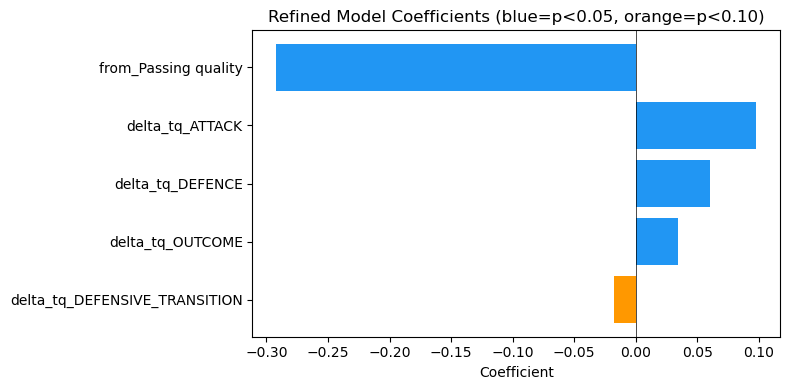

In [20]:
# Coefficient plot
fig, ax = plt.subplots(figsize=(8, 4))
features = coef_df_feat["Feature"].values
coefs = coef_df_feat["Coefficient"].values
pvals = coef_df_feat["p-value"].values

colors = ["#2196F3" if p < 0.05 else "#FF9800" if p < 0.10 else "#BDBDBD" for p in pvals]
ax.barh(range(len(features)), coefs, color=colors)
ax.set_yticks(range(len(features)))
ax.set_yticklabels(features, fontsize=10)
ax.axvline(0, color="black", linewidth=0.5)
ax.set_xlabel("Coefficient")
ax.set_title("Refined Model Coefficients (blue=p<0.05, orange=p<0.10)")
ax.invert_yaxis()
plt.tight_layout()
plt.show()

---
## Diagnostics

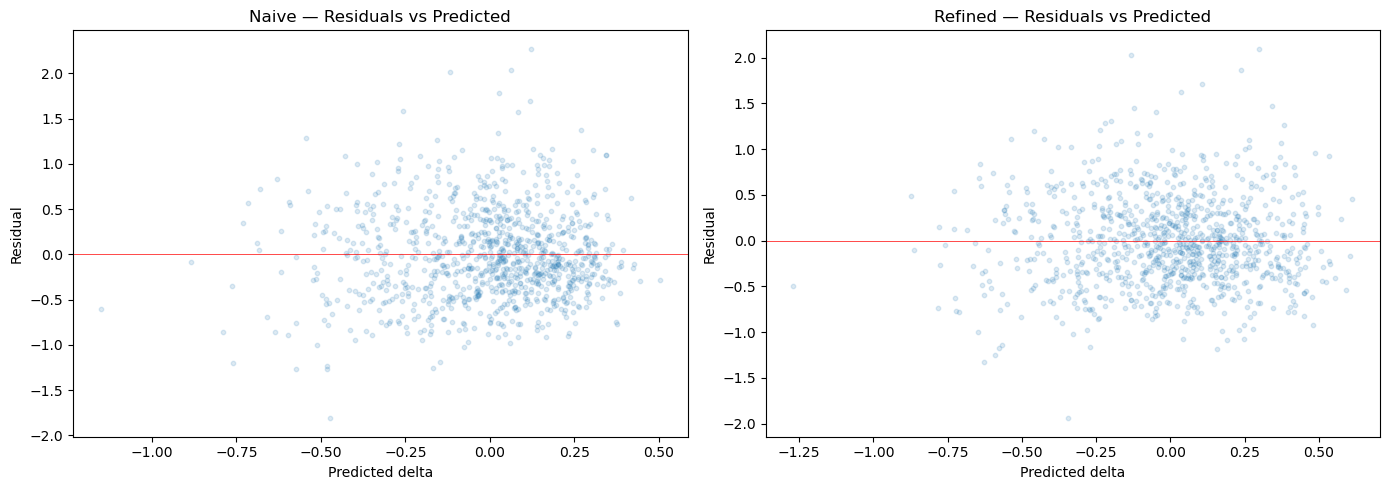

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, pred in [(axes[0], "Naive", naive_pred), (axes[1], "Refined", refined_pred)]:
    resid = y_test - pred
    ax.scatter(pred, resid, alpha=0.15, s=10)
    ax.axhline(0, color="red", linewidth=0.5)
    ax.set_xlabel("Predicted delta")
    ax.set_ylabel("Residual")
    ax.set_title(f"{name} — Residuals vs Predicted")

plt.tight_layout()
plt.show()

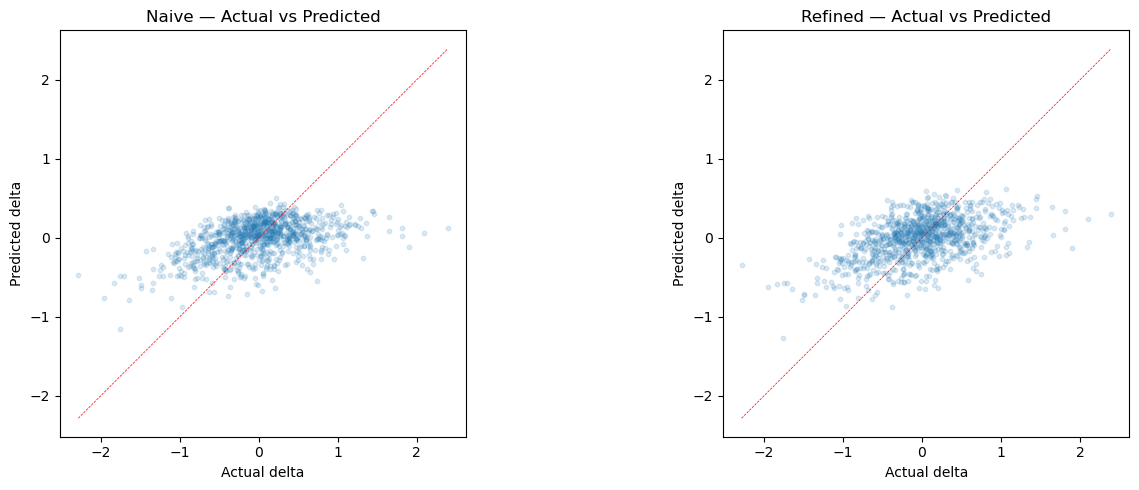

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, name, pred in [(axes[0], "Naive", naive_pred), (axes[1], "Refined", refined_pred)]:
    ax.scatter(y_test, pred, alpha=0.15, s=10)
    lims = [min(y_test.min(), pred.min()), max(y_test.max(), pred.max())]
    ax.plot(lims, lims, "r--", linewidth=0.5)
    ax.set_xlabel("Actual delta")
    ax.set_ylabel("Predicted delta")
    ax.set_title(f"{name} — Actual vs Predicted")
    ax.set_aspect("equal")

plt.tight_layout()
plt.show()

---
## Model 3: Minimal (Pre-Quality + 3 Delta TQ, no Defensive Transition)

In [23]:
minimal_tq = ["delta_tq_ATTACK", "delta_tq_DEFENCE", "delta_tq_OUTCOME"]
minimal_features = ["from_Passing quality"] + minimal_tq

X_train_min = sm.add_constant(train[minimal_features])
X_test_min  = sm.add_constant(test[minimal_features])

minimal_model = sm.OLS(y_train, X_train_min).fit()
minimal_pred = minimal_model.predict(X_test_min)
minimal_r2  = r2_score(y_test, minimal_pred)
minimal_mae = mean_absolute_error(y_test, minimal_pred)

print(minimal_model.summary())
print(f"\nTest R²: {minimal_r2:.4f}  |  Test MAE: {minimal_mae:.4f}")

                              OLS Regression Results                             
Dep. Variable:     delta_Passing_quality   R-squared:                       0.217
Model:                               OLS   Adj. R-squared:                  0.216
Method:                    Least Squares   F-statistic:                     272.2
Date:                   Fri, 20 Mar 2026   Prob (F-statistic):          9.58e-207
Time:                           12:14:33   Log-Likelihood:                -2885.1
No. Observations:                   3932   AIC:                             5780.
Df Residuals:                       3927   BIC:                             5812.
Df Model:                              4                                         
Covariance Type:               nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
co

---
## 3-Way Comparison

In [24]:
comparison_3 = pd.DataFrame({
    "Model": ["1. Naive", "2. Refined (4 delta TQ)", "3. Minimal (3 delta TQ)"],
    "R2_test": [naive_r2, refined_r2, minimal_r2],
    "MAE_test": [naive_mae, refined_mae, minimal_mae],
    "R2_adj_train": [naive_model.rsquared_adj, refined_model.rsquared_adj, minimal_model.rsquared_adj],
    "AIC": [naive_model.aic, refined_model.aic, minimal_model.aic],
    "BIC": [naive_model.bic, refined_model.bic, minimal_model.bic],
    "N_features": [len(naive_features), len(refined_features), len(minimal_features)],
})
print(comparison_3.to_string(index=False, float_format="{:.4f}".format))

print(f"\nR² gain (refined vs naive):  {refined_r2 - naive_r2:+.4f}")
print(f"R² gain (minimal vs naive):  {minimal_r2 - naive_r2:+.4f}")
print(f"R² cost of dropping DEF_TRANS: {minimal_r2 - refined_r2:+.4f}")

                  Model  R2_test  MAE_test  R2_adj_train       AIC       BIC  N_features
               1. Naive   0.2023    0.3924        0.1557 6069.6131 6082.1669           1
2. Refined (4 delta TQ)   0.2448    0.3835        0.2166 5779.2035 5816.8650           5
3. Minimal (3 delta TQ)   0.2449    0.3838        0.2162 5780.1505 5811.5351           4

R² gain (refined vs naive):  +0.0425
R² gain (minimal vs naive):  +0.0426
R² cost of dropping DEF_TRANS: +0.0001


---
## Model 4: Direct to_Q (same features, predict level instead of delta)

$$\text{to\_PQ} = \alpha + \beta \cdot \text{from\_PQ} + \gamma_1 \Delta\text{ATTACK} + \gamma_2 \Delta\text{DEFENCE} + \gamma_3 \Delta\text{OUTCOME}$$

In [25]:
# Same features, but target is to_Passing_quality directly
direct_features = ["from_Passing quality", "delta_tq_ATTACK", "delta_tq_DEFENCE", "delta_tq_OUTCOME"]

X_train_dir = sm.add_constant(train[direct_features])
X_test_dir  = sm.add_constant(test[direct_features])
y_train_dir = train["to_Passing quality"]
y_test_dir  = test["to_Passing quality"]

direct_model = sm.OLS(y_train_dir, X_train_dir).fit()
direct_pred = direct_model.predict(X_test_dir)
direct_r2  = r2_score(y_test_dir, direct_pred)
direct_mae = mean_absolute_error(y_test_dir, direct_pred)

print(direct_model.summary())
print(f"\nTest R²: {direct_r2:.4f}  |  Test MAE: {direct_mae:.4f}")

                            OLS Regression Results                            
Dep. Variable:     to_Passing quality   R-squared:                       0.507
Model:                            OLS   Adj. R-squared:                  0.507
Method:                 Least Squares   F-statistic:                     1012.
Date:                Fri, 20 Mar 2026   Prob (F-statistic):               0.00
Time:                        12:14:33   Log-Likelihood:                -2885.1
No. Observations:                3932   AIC:                             5780.
Df Residuals:                    3927   BIC:                             5812.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                           coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------
const                   -0.0098 

---
## 4-Way Comparison

In [26]:
# For fair comparison, convert delta models to to_Q predictions
naive_to_pred = test["from_Passing quality"] + naive_pred
minimal_to_pred = test["from_Passing quality"] + minimal_pred

naive_to_r2 = r2_score(y_test_dir, naive_to_pred)
naive_to_mae = mean_absolute_error(y_test_dir, naive_to_pred)
minimal_to_r2 = r2_score(y_test_dir, minimal_to_pred)
minimal_to_mae = mean_absolute_error(y_test_dir, minimal_to_pred)

comparison_4 = pd.DataFrame({
    "Model": [
        "1. Naive (delta target)",
        "3. Minimal (delta target)",
        "4. Direct (to_Q target)",
    ],
    "R2_on_to_Q": [naive_to_r2, minimal_to_r2, direct_r2],
    "MAE_on_to_Q": [naive_to_mae, minimal_to_mae, direct_mae],
})
print("All evaluated on to_Passing_quality:")
print(comparison_4.to_string(index=False, float_format="{:.4f}".format))

All evaluated on to_Passing_quality:
                    Model  R2_on_to_Q  MAE_on_to_Q
  1. Naive (delta target)      0.4825       0.3924
3. Minimal (delta target)      0.5101       0.3838
  4. Direct (to_Q target)      0.5101       0.3838
